# Global Volcanic Eruptions: 12,000 Years of Earth's History

11,089 documented eruptions across 1,196 volcanoes, spanning the Holocene period, cleaned and joined from the Smithsonian Global Volcanism Program (GVP). Full cleaning methodology and column documentation are in the companion dataset: 
[Global Volcanic Eruptions: Holocene Record](https://www.kaggle.com/datasets/zaneneave/global-volcanic-eruptions-holocene-record)

This notebook explores:
- Where volcanic activity concentrates globally
- How eruption explosivity (VEI) is distributed
- Which tectonic settings produce the most/biggest eruptions
- How reliable our historical eruption dates actually are

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.facecolor"] = "#0d1117"
plt.rcParams["axes.facecolor"] = "#161b22"
plt.rcParams["axes.edgecolor"] = "#30363d"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["text.color"] = "white"
plt.rcParams["xtick.color"] = "#8b949e"
plt.rcParams["ytick.color"] = "#8b949e"
plt.rcParams["axes.titlecolor"] = "white"
plt.rcParams["grid.color"] = "#21262d"

df = pd.read_csv("/kaggle/input/datasets/zaneneave/global-volcanic-eruptions-holocene-record/global_volcanic_eruptions_holocene.csv")

print(f"{len(df):,} eruptions loaded across {df['Volcano_Number'].nunique():,} volcanoes")
print(f"Date range: {df['StartDateYear'].min():.0f} to {df['StartDateYear'].max():.0f}")
df.head()

11,089 eruptions loaded across 915 volcanoes
Date range: -55500 to 2026


,FID,Volcano_Number,Volcano_Name,Eruption_Number,Activity_Type,ExplosivityIndexMax,ExplosivityIndexModifier,ActivityArea,ActivityUnit,StartEvidenceMethod,...,Region,Subregion,Primary_Volcano_Type,Tectonic_Setting,Latitude,Longitude,Elevation,Major_Rock_Type,pre_holocene_outlier,start_date_precision
0,Smithsonian_VOTW_Holocene_Eruptions.fid-5cc20e...,210010,West Eifel Volcanic Field,10001,Confirmed Eruption,NaN,NaN,Ulmener Maar,NaN,Isotopic: 14C (calibrated),...,European Volcanic Regions,Central European Volcanic Province,Volcanic field,Rift zone / Continental crust (> 25 km),50.170,6.850,600.0,Foidite,False,day
1,Smithsonian_VOTW_Holocene_Eruptions.fid-5cc20e...,210010,West Eifel Volcanic Field,10002,Confirmed Eruption,NaN,NaN,"Strohn, Pulvermaar",NaN,Isotopic: 14C (uncalibrated),...,European Volcanic Regions,Central European Volcanic Province,Volcanic field,Rift zone / Continental crust (> 25 km),50.170,6.850,600.0,Foidite,False,day
2,Smithsonian_VOTW_Holocene_Eruptions.fid-5cc20e...,210020,Chaine des Puys,10003,Confirmed Eruption,NaN,NaN,Western Puy de Dôme,NaN,Isotopic: 14C (uncalibrated),...,European Volcanic Regions,Western European Volcanic Province,Lava dome(s),Rift zone / Continental crust (> 25 km),45.786,2.981,1464.0,Basalt / Picro-Basalt,False,day
3,Smithsonian_VOTW_Holocene_Eruptions.fid-5cc20e...,210020,Chaine des Puys,10004,Confirmed Eruption,NaN,NaN,Puy Mey,NaN,Radiogenic: Thermoluminescence,...,European Volcanic Regions,Western European Volcanic Province,Lava dome(s),Rift zone / Continental crust (> 25 km),45.786,2.981,1464.0,Basalt / Picro-Basalt,False,day
4,Smithsonian_VOTW_Holocene_Eruptions.fid-5cc20e...,210020,Chaine des Puys,10005,Confirmed Eruption,NaN,NaN,NaN,Taphanel tephra,Isotopic: 14C (uncalibrated),...,European Volcanic Regions,Western European Volcanic Province,Lava dome(s),Rift zone / Continental crust (> 25 km),45.786,2.981,1464.0,Basalt / Picro-Basalt,False,day


## Quick Overview

A snapshot of the dataset: how explosive these eruptions typically are, which volcano types dominate and which regions have seen the most activity.

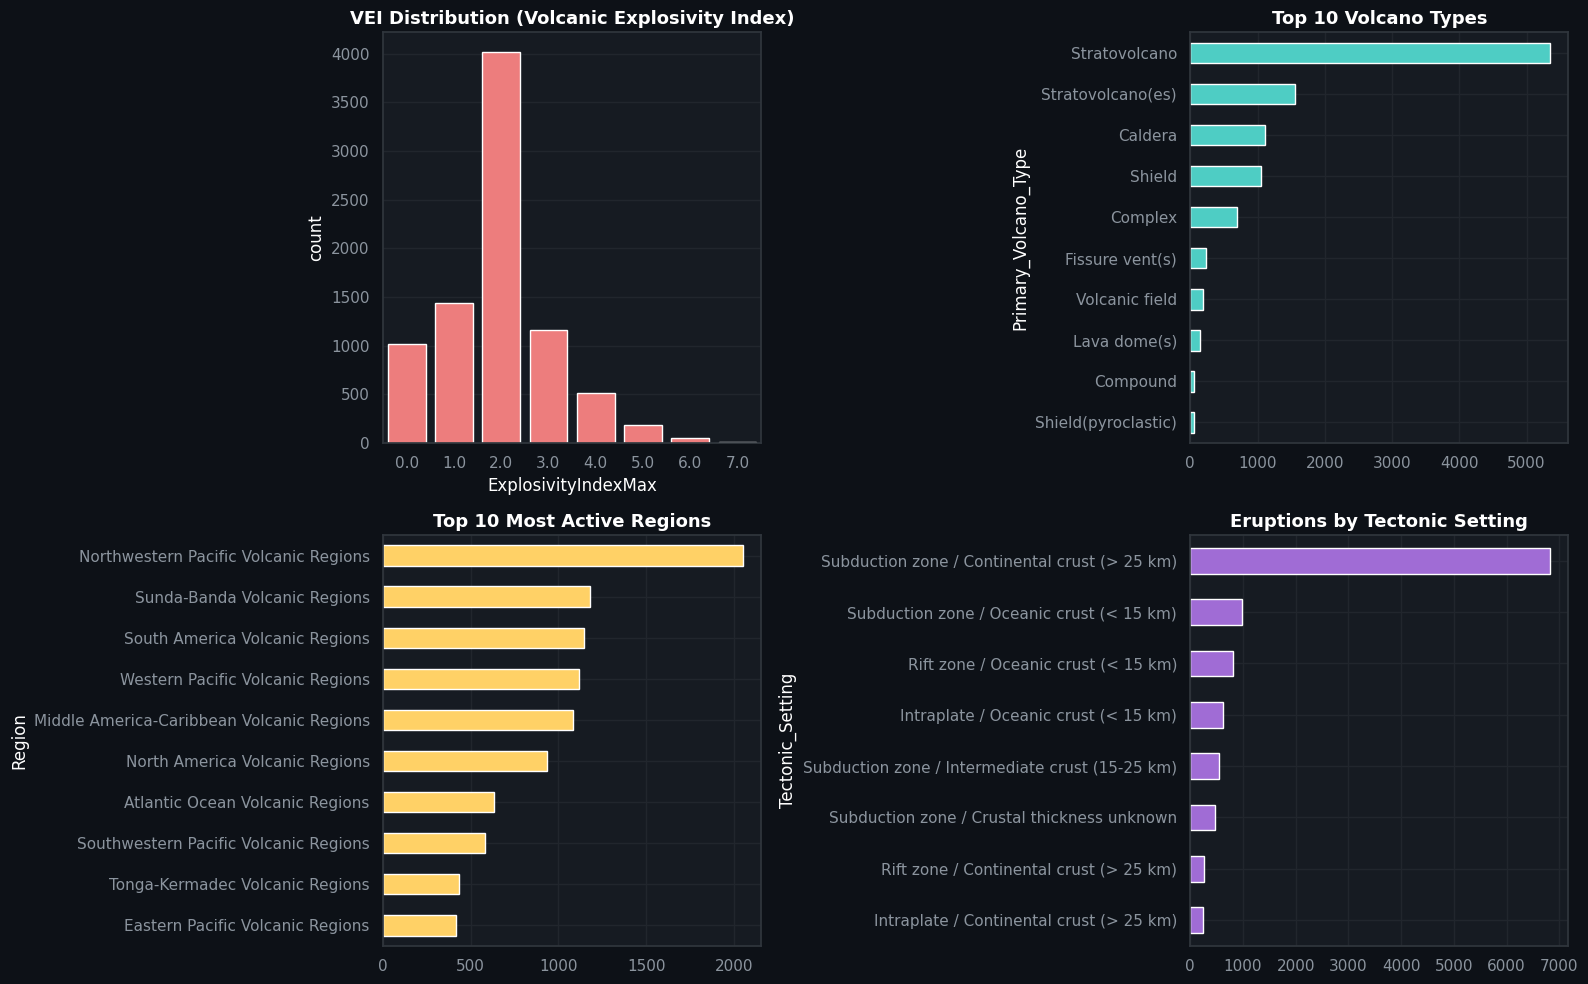

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=df.dropna(subset=["ExplosivityIndexMax"]), x="ExplosivityIndexMax",
              color="#ff6b6b", ax=axes[0,0])
axes[0,0].set_title("VEI Distribution (Volcanic Explosivity Index)", fontsize=13, fontweight="bold")

df["Primary_Volcano_Type"].value_counts().head(10).plot(kind="barh", color="#4ecdc4", ax=axes[0,1])
axes[0,1].invert_yaxis()
axes[0,1].set_title("Top 10 Volcano Types", fontsize=13, fontweight="bold")

df["Region"].value_counts().head(10).plot(kind="barh", color="#ffd166", ax=axes[1,0])
axes[1,0].invert_yaxis()
axes[1,0].set_title("Top 10 Most Active Regions", fontsize=13, fontweight="bold")

df["Tectonic_Setting"].value_counts().head(8).plot(kind="barh", color="#a06cd5", ax=axes[1,1])
axes[1,1].invert_yaxis()
axes[1,1].set_title("Eruptions by Tectonic Setting", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## Where does volcanic activity concentrate?

Like earthquakes, volcanoes trace tectonic plate boundaries, but the pattern here reflects magma generation zones specifically, sized and colored by eruption explosivity (VEI).

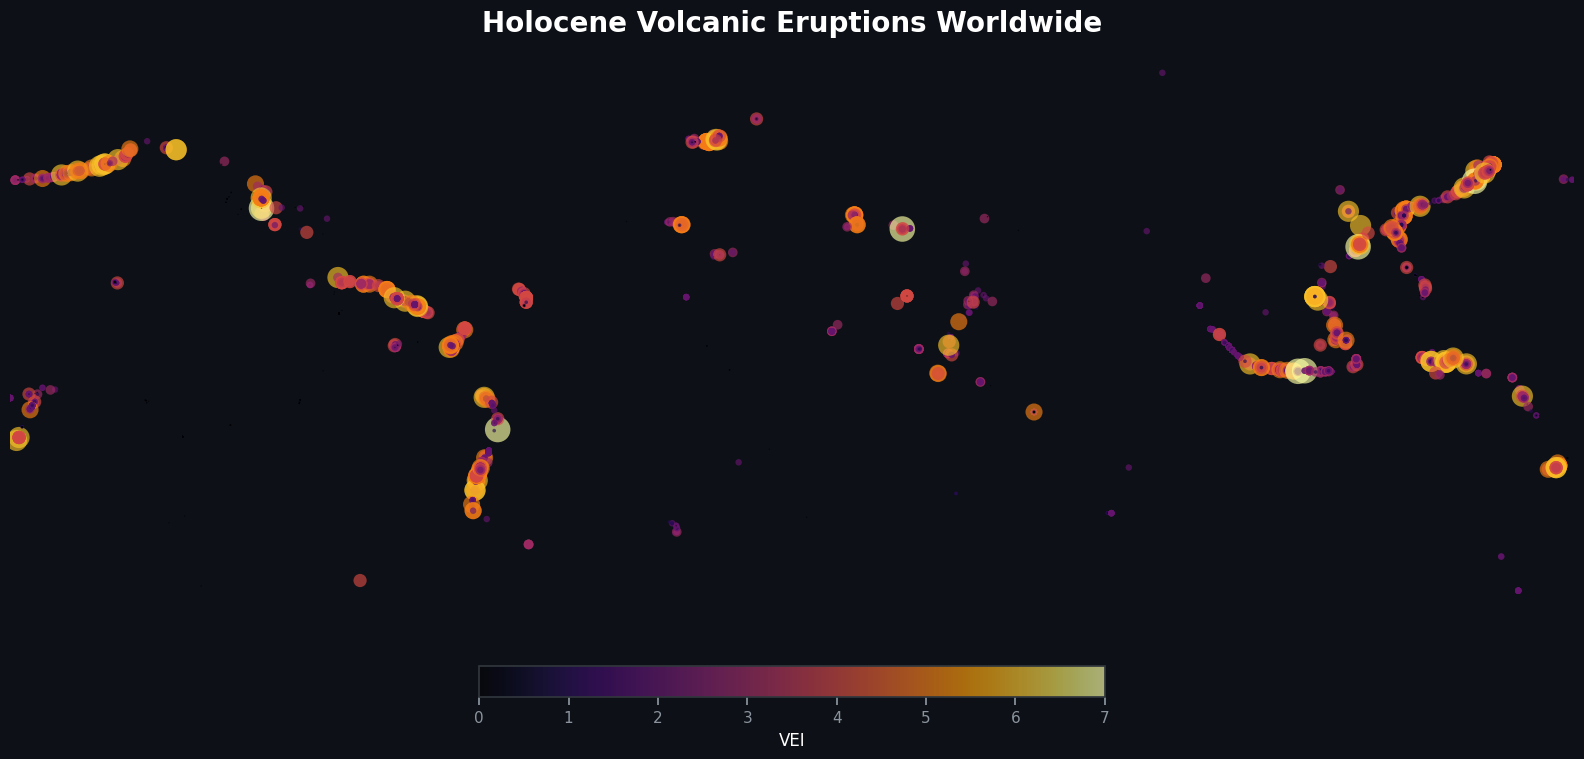

In [3]:
plot_data = df.dropna(subset=["ExplosivityIndexMax", "Latitude", "Longitude"])

fig, ax = plt.subplots(figsize=(16, 8), facecolor="#0d1117")
ax.set_facecolor("#0d1117")

scatter = ax.scatter(
    plot_data["Longitude"], plot_data["Latitude"],
    s=(plot_data["ExplosivityIndexMax"] + 1) ** 2.8,
    c=plot_data["ExplosivityIndexMax"], cmap="inferno", alpha=0.65, edgecolors="none"
)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05, shrink=0.4)
cbar.set_label("VEI", color="white")

ax.set_title("Holocene Volcanic Eruptions Worldwide", fontsize=20, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## Does tectonic setting affect eruption explosivity?

Not all volcanic settings are equal, subduction zone volcanoes are generally known for more explosive eruptions than rift/intraplate settings, since subduction magmas tend to be more viscous and gas-rich. Let's check if the data backs that up.

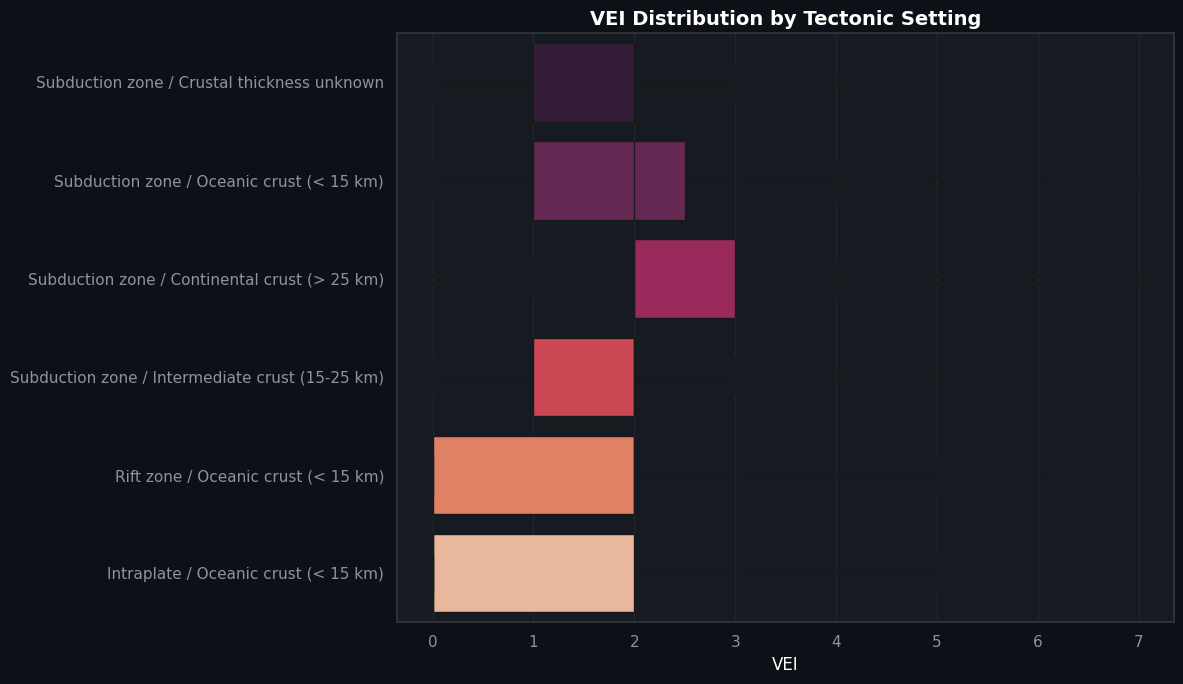

In [4]:
top_settings = df["Tectonic_Setting"].value_counts().head(6).index
subset = df[df["Tectonic_Setting"].isin(top_settings) & df["ExplosivityIndexMax"].notna()]

plt.figure(figsize=(12, 7))
sns.boxplot(data=subset, y="Tectonic_Setting", x="ExplosivityIndexMax", 
            hue="Tectonic_Setting", palette="rocket", legend=False)
plt.title("VEI Distribution by Tectonic Setting", fontsize=14, fontweight="bold")
plt.xlabel("VEI"); plt.ylabel("")
plt.tight_layout()
plt.show()

## How has eruption frequency changed over recorded history?

Since this spans 12,000 years, raw data is naturally sparse in ancient periods (less was observed/preserved) and denser in modern times (better monitoring). Rather than imply ancient volcanoes were "less active," this is largely a detection/preservation effect worth being upfront about.

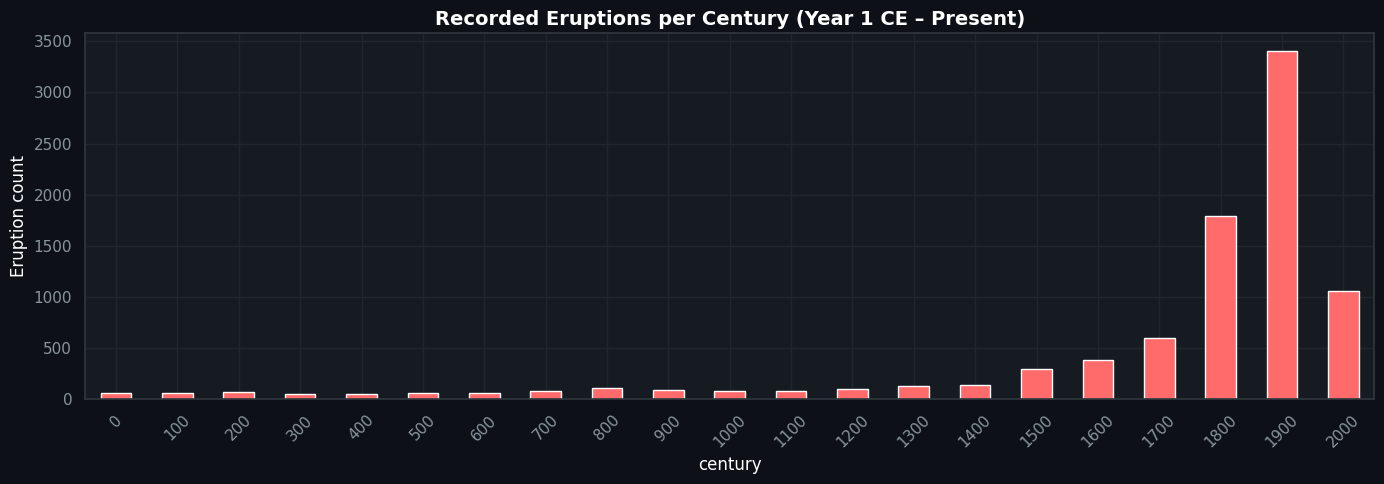

In [5]:
recent = df[df["StartDateYear"] >= 1].copy()
recent["century"] = (recent["StartDateYear"] // 100) * 100

plt.figure(figsize=(14, 5))
recent["century"].value_counts().sort_index().plot(kind="bar", color="#ff6b6b")
plt.title("Recorded Eruptions per Century (Year 1 CE – Present)", fontsize=14, fontweight="bold")
plt.ylabel("Eruption count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## How much can we actually trust these historical dates?

A meaningful share of eruption dates in this dataset are placeholders rather than precisely observed dates, the source data marks year-only or month-only precision using conventional placeholder dates. Here's the actual breakdown.

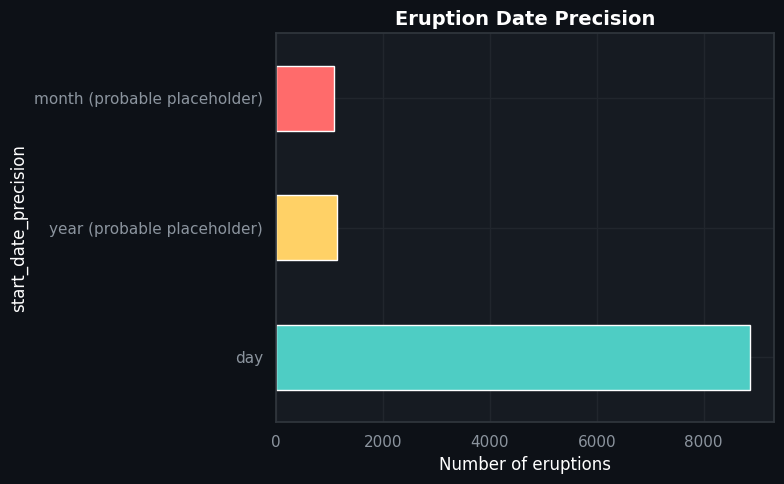

start_date_precision
day                             8871
year (probable placeholder)     1140
month (probable placeholder)    1078
Name: count, dtype: int64

80.0% of eruptions have exact day-level precision


In [6]:
precision_counts = df["start_date_precision"].value_counts()

plt.figure(figsize=(8, 5))
precision_counts.plot(kind="barh", color=["#4ecdc4", "#ffd166", "#ff6b6b"])
plt.title("Eruption Date Precision", fontsize=14, fontweight="bold")
plt.xlabel("Number of eruptions")
plt.tight_layout()
plt.show()

print(precision_counts)
print(f"\n{(precision_counts.get('day', 0) / len(df) * 100):.1f}% of eruptions have exact day-level precision")

## The most explosive eruptions on record

A quick look at the highest-VEI eruptions in the dataset, these represent the most significant, well-documented events.

In [7]:
top_eruptions = df[df["ExplosivityIndexMax"].notna()].nlargest(10, "ExplosivityIndexMax")
top_eruptions[["Volcano_Name", "Country", "StartDateYear", "ExplosivityIndexMax", "Primary_Volcano_Type"]]

,Volcano_Name,Country,StartDateYear,ExplosivityIndexMax,Primary_Volcano_Type
420,"Blanco, Cerro",Argentina,-2300,7.0,Caldera
2256,Santorini,Greece,-1610,7.0,Shield(s)
2515,Crater Lake,United States,-5680,7.0,Caldera
7938,Kikai,Japan,-4350,7.0,Caldera
8059,Kurile Lake,Russia,-6440,7.0,Caldera
9915,Rinjani,Indonesia,1257,7.0,Stratovolcano
9937,Tambora,Indonesia,1812,7.0,Stratovolcano
324,Ulleungdo,South Korea,-8750,6.0,Stratovolcano
417,Ilopango,El Salvador,450,6.0,Caldera
1068,Khangar,Russia,-5700,6.0,Stratovolcano


## Have fun